# Phase-dependent modulation of action potential threshold by rhythmic inhibition

This notebook analyzes how rhythmic inhibition at different frequencies (beta ~16 Hz and gamma ~64 Hz) modulates the threshold voltage for action potential initiation in a simulated layer 5 pyramidal neuron. As described in the paper, gamma rhythmic inhibition delivered perisomatically modulates somatic excitability by shifting the action potential voltage threshold in a phase-dependent manner. During the 'trough' phase of gamma (when inhibition is weakest), the somatic action potential voltage threshold shifts lower without changes in mean membrane voltage. This is consistent with gamma phase modulating the shunting of voltage-gated Na+ channel currents. Beta rhythmic inhibition delivered to distal dendrites has different effects: during the 'peak' phase of beta (when inhibition is maximal), the threshold for evoking an action potential increases, potentially reflecting an 'off-path' shunting of excitatory current away from the soma and towards the dendrites. Additionally, there is a decrease in membrane voltage during the peak phase, which may correspond to decreased excitation arising from the suppression of dendritic spikes.

The simulations include three conditions:
1. 16 Hz beta rhythmic inhibition (20% depth of modulation) delivered to distal dendrites (>100 µm from soma)
2. 64 Hz gamma rhythmic inhibition (40% depth of modulation) delivered perisomatically (soma and proximal dendrites within 100 µm)
3. Poisson (non-rhythmic) inhibition as a control condition

This analysis stratifies action potential voltage thresholds and membrane voltage distributions by the phase (peak or trough) of the inhibitory rhythm to reveal phase-dependent modulation of somatic excitability.

In [1]:
import sys
sys.path.append('..') # have to do this for relative imports in jupyter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from src.load_spike_h5 import load_spike_h5
from src.load_v_h5 import load_v_h5
from src.load_axcurrent_csv import load_axcurrent_csv
from src.count_dendevt_files import count_dendevt_files

## 1.0 Analysis parameters

Define analysis windows and constants for processing simulation data.

### 1.1 Simulation constants and analysis windows

Set sampling rate, voltage/current bin edges, and simulation window for analysis.

In [2]:
samps_per_ms = 10 
edges_v = np.arange(-80,-40,0.5)
edges_i = np.linspace(-3,3,160)
sim_win = [0, 2000000] # beginning and start points of simulation in samples

### 1.2 List files to be processed

Define paths to simulation output files for the three experimental conditions: 16 Hz beta rhythmic inhibition, 64 Hz gamma rhythmic inhibition, and Poisson (non-rhythmic) control.

In [13]:
# locate simulation files
root_16_dir = 'D:\\DendCompOscPublic\\output_16Hz_no_exc_mod\\'
sim_16_dict = {'SimName': 'output_16Hz_no_exc_mod',
               'RootDir': root_16_dir,
               'CaFile': root_16_dir + 'output_16Hz_no_exc_mod_ca.csv',
               'NaFile': root_16_dir + 'output_16Hz_no_exc_mod_na.csv',
               'NMDAFile': root_16_dir + 'output_16Hz_no_exc_mod_nmda.csv',
               'APFile': root_16_dir + 'spikes.h5',
               'VMemFile': root_16_dir + 'output_16Hz_no_exc_mod_soma_v.csv',
               'AxCurrFile': root_16_dir + 'axial_currents.csv'}

root_64_dir = 'D:\\DendCompOscPublic\\output_64Hz_no_exc_mod_dom_40p\\'
sim_64_dict = {'SimName': 'output_64Hz_no_exc_mod_dom_40p',
               'RootDir': root_64_dir,
               'CaFile': root_64_dir + 'output_64Hz_no_exc_mod_dom_40p_ca.csv',
               'NaFile': root_64_dir + 'output_64Hz_no_exc_mod_dom_40p_na.csv',
               'NMDAFile': root_64_dir + 'output_64Hz_no_exc_mod_dom_40p_nmda.csv',
               'APFile': root_64_dir + 'spikes.h5',
               'VMemFile': root_64_dir + 'output_64Hz_no_exc_mod_dom_40p_soma_v.csv',
               'AxCurrFile': root_64_dir + 'axial_currents.csv'}

root_pois_dir = 'D:\\DendCompOscPublic\\output_allpoisson\\'
sim_pois_dict = {'SimName': 'output_allpoisson',
               'RootDir': root_pois_dir,
               'CaFile': root_pois_dir + 'output_allpoisson_ca.csv',
               'NaFile': root_pois_dir + 'output_allpoisson_na.csv',
               'NMDAFile': root_pois_dir + 'output_allpoisson_nmda.csv',
               'APFile': root_pois_dir + 'spikes.h5',
               'VMemFile': root_pois_dir + 'output_allpoisson_soma_v.csv',
               'AxCurrFile': root_pois_dir + 'axial_currents.csv'}



## 2.0 Phase-dependent action potential threshold and membrane voltage distributions

Calculate action potential voltage threshold and somatic membrane voltage distributions as a function of rhythmic inhibition phase. As shown in Figure 6 of the paper, gamma rhythmic inhibition delivered perisomatically produces phase-dependent shifts in action potential threshold without changing mean membrane voltage, while beta rhythmic inhibition delivered to distal dendrites affects both threshold and membrane voltage in a phase-dependent manner.

### 2.1 Generate phase series for each experiment

Create sinusoidal time series at 16 Hz (beta) and 64 Hz (gamma) frequencies to divide simulation time into rhythm phases. These phase series are used to categorize action potentials and membrane voltages as occurring during either the 'peak' phase (when inhibition is greater than mean) or 'trough' phase (when inhibition is lower than mean).

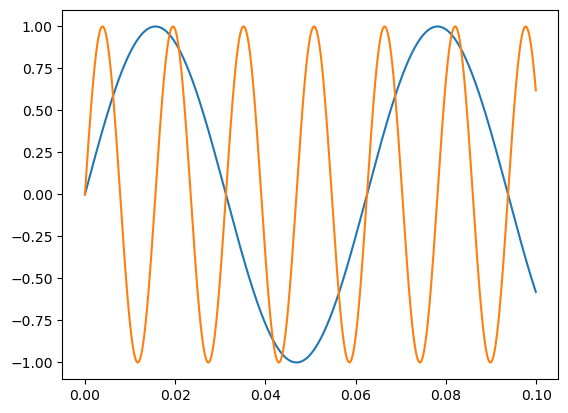

In [14]:
# generate phase time series for inhibitory afferents
t_ser = np.arange(sim_win[0], sim_win[1], 1) / 10000 # seconds
sin_16_ser = np.sin(t_ser*16*2*np.pi)
sin_64_ser = np.sin(t_ser*64*2*np.pi)

fig, ax = plt.subplots()
ax.plot(t_ser[0:1000],sin_16_ser[0:1000])
ax.plot(t_ser[0:1000],sin_64_ser[0:1000])
plt.show()

### 2.2 Calculate action potential threshold voltage and membrane voltage distributions

Define functions to calculate action potential probability as a function of membrane voltage, and to compute voltage distributions stratified by rhythm phase. Action potential threshold is taken as the voltage 1 ms prior to the spike peak. For rhythmic inhibition conditions, these metrics are separated by whether they occurred during the peak or trough phase of the rhythm, revealing phase-dependent modulation of somatic excitability.

In [15]:
# probability of action potentials by membrane voltage
def ap_prob_func(spk, v, edges):
    null_hist = np.histogram(v, edges)
    spk_hist = np.histogram(v[spk-10], edges)
    spk_cum_prob = np.nancumsum(spk_hist[0]/null_hist[0])
    return {'null': null_hist[0], 'spk': spk_hist[0], 'prob': spk_cum_prob}

def thresh_files_func(sim_dict, sin_ser):
    spk_prob = {'v': {}, 'i_apic': {}, 'i_basal': {}}

    # split action potentials based on phase of rhythm
    spk_t = load_spike_h5(sim_dict['APFile'])
    p_inds = np.where(sin_ser >= 0)
    t_inds = np.where(sin_ser < 0)
    spk_t_p = np.intersect1d(spk_t, p_inds)
    spk_t_t = np.intersect1d(spk_t, t_inds)
    
    # load soma voltage from CSV file
    mem_v = pd.read_csv(sim_dict['VMemFile'])['voltage_mV'].values
 
    # calculate action potential probability by voltage for each phase
    spk_prob['v']['p'] = ap_prob_func(spk_t_p, mem_v, edges_v)
    spk_prob['v']['t'] = ap_prob_func(spk_t_t, mem_v, edges_v)

    # membrane voltage distribution by phase
    spk_prob['v']['p']['dist'] = np.histogram(mem_v[p_inds], edges_v)[0]
    spk_prob['v']['t']['dist'] = np.histogram(mem_v[t_inds], edges_v)[0]

    return spk_prob

def thresh_files_pois_func(sim_dict):
    spk_prob = {'v': {}, 'i_apic': {}, 'i_basal': {}}

    # split action potentials based on phase of rhythm
    spk_t = load_spike_h5(sim_dict['APFile'])
   
    # load soma voltage from CSV file
    mem_v = pd.read_csv(sim_dict['VMemFile'])['voltage_mV'].values

    # calculate action potential probability by voltage
    spk_prob['v']['pois'] = ap_prob_func(spk_t, mem_v, edges_v)
   
    # membrane voltage distribution
    spk_prob['v']['pois']['dist'] = np.histogram(mem_v, edges_v)[0]

    return spk_prob

In [16]:
# process the 16 Hz distal dendritic inhibition simulation
ph16_prob = thresh_files_func(sim_16_dict, sin_16_ser)

# process the 64 Hz proximal dendritic/somatic inhibition simulation
ph64_prob = thresh_files_func(sim_64_dict, sin_64_ser)

# process the poisson inhibition simulation
pois_prob = thresh_files_pois_func(sim_pois_dict)

### 2.3 Plots

Visualize phase-dependent modulation of action potential threshold and somatic membrane voltage by beta and gamma rhythmic inhibition.

In [17]:
# plotting functions
# set meas to 'v' for voltage, and 'i' for current
def ap_prob_ph_plot(ph_prob, ax, meas='v'):
        if meas=='v':
                edges = edges_v[:-1]
        elif meas=='i_apic' or meas=='i_basal':
                edges = edges_i[:-1]
        
        ax.plot(edges, ph_prob[meas]['p']['prob']/np.max(ph_prob[meas]['p']['prob']),color='r')
        ax.plot(edges, ph_prob[meas]['t']['prob']/np.max(ph_prob[meas]['t']['prob']),color='b')
        ax.plot(edges, pois_prob[meas]['pois']['prob']/np.max(pois_prob[meas]['pois']['prob']),color='k')

def meas_prob_ph_plot(ph_prob, ax, meas='v'):
        if meas=='v':
                edges = edges_v[:-1]
        elif meas=='i_apic' or meas=='i_basal':
                edges = edges_i[:-1]

        ax.plot(edges, ph_prob[meas]['p']['dist']/np.max(ph_prob[meas]['p']['dist']),color='r')
        ax.plot(edges, ph_prob[meas]['t']['dist']/np.max(ph_prob[meas]['t']['dist']),color='b')
        ax.plot(edges, pois_prob[meas]['pois']['dist']/np.max(pois_prob[meas]['pois']['dist']),color='k')

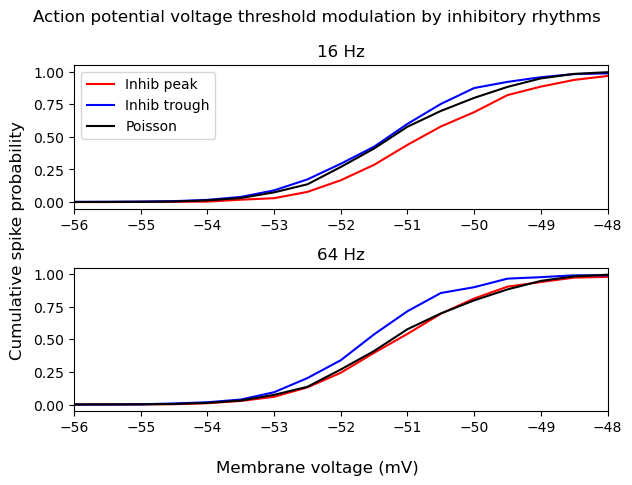

In [18]:
# Action potential probabilities by membrane voltage and phase
fig, ax = plt.subplots(2,1,sharey=True)
ap_prob_ph_plot(ph16_prob, ax[0])
ap_prob_ph_plot(ph64_prob, ax[1])
ax[0].set_title('16 Hz')
ax[1].set_title('64 Hz')
ax[0].set_xlim([-56, -48])
ax[1].set_xlim([-56, -48])
fig.suptitle('Action potential voltage threshold modulation by inhibitory rhythms')
fig.supxlabel('Membrane voltage (mV)')
fig.supylabel('Cumulative spike probability')
ax[0].legend(('Inhib peak', 'Inhib trough', 'Poisson'))
plt.tight_layout()

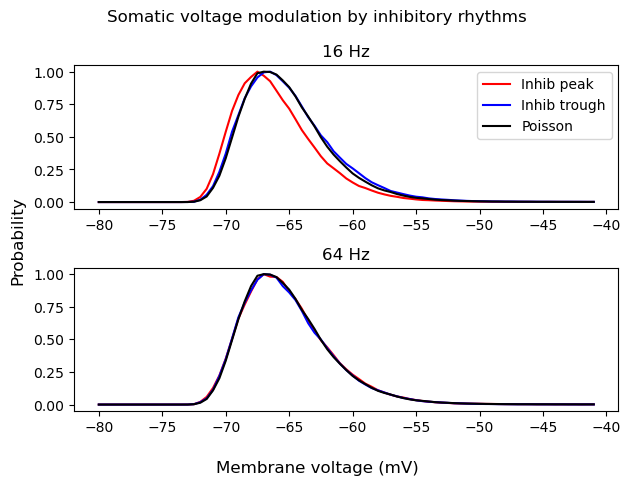

In [19]:
# Membrane voltage by phase
fig, ax = plt.subplots(2,1,sharey=True)
meas_prob_ph_plot(ph16_prob, ax[0])
meas_prob_ph_plot(ph64_prob, ax[1])
ax[0].set_title('16 Hz')
ax[1].set_title('64 Hz')
fig.suptitle('Somatic voltage modulation by inhibitory rhythms')
fig.supxlabel('Membrane voltage (mV)')
fig.supylabel('Probability')
ax[0].legend(('Inhib peak', 'Inhib trough', 'Poisson'))
plt.tight_layout()
plt.show()

## 3.0 Export membrane voltage data to CSV

Load and export somatic membrane voltage data from all three simulation conditions to separate CSV files for further analysis or sharing.

In [12]:
# Load membrane voltage data from all three simulation conditions and save as separate CSV files
import os

# Get the current notebook directory
notebook_dir = os.getcwd()

# Load membrane voltage data from soma (segment 0) for each condition
print("Loading membrane voltage data...")
mem_v_16hz = load_v_h5(sim_16_dict['VMemFile'], 0)
mem_v_64hz = load_v_h5(sim_64_dict['VMemFile'], 0)
mem_v_pois = load_v_h5(sim_pois_dict['VMemFile'], 0)

# Round to 2 decimal places and save each as separate CSV
# 16 Hz condition
df_16hz = pd.DataFrame({'voltage_mV': np.round(mem_v_16hz, 2)})
csv_16hz = os.path.join(notebook_dir, 'Fig6_membrane_voltage_16Hz.csv')
df_16hz.to_csv(csv_16hz, index=False)
print(f"Saved 16 Hz data: {csv_16hz} (shape: {df_16hz.shape})")

# 64 Hz condition
df_64hz = pd.DataFrame({'voltage_mV': np.round(mem_v_64hz, 2)})
csv_64hz = os.path.join(notebook_dir, 'Fig6_membrane_voltage_64Hz.csv')
df_64hz.to_csv(csv_64hz, index=False)
print(f"Saved 64 Hz data: {csv_64hz} (shape: {df_64hz.shape})")

# Poisson condition
df_pois = pd.DataFrame({'voltage_mV': np.round(mem_v_pois, 2)})
csv_pois = os.path.join(notebook_dir, 'Fig6_membrane_voltage_Poisson.csv')
df_pois.to_csv(csv_pois, index=False)
print(f"Saved Poisson data: {csv_pois} (shape: {df_pois.shape})")

print("\nAll membrane voltage data saved successfully!")

Loading membrane voltage data...
Saved 16 Hz data: c:\Users\dbh60\Documents\Analysis\InhibOnDendComp\scripts\Fig6_membrane_voltage_16Hz.csv (shape: (2000000, 1))
Saved 64 Hz data: c:\Users\dbh60\Documents\Analysis\InhibOnDendComp\scripts\Fig6_membrane_voltage_64Hz.csv (shape: (2000000, 1))
Saved Poisson data: c:\Users\dbh60\Documents\Analysis\InhibOnDendComp\scripts\Fig6_membrane_voltage_Poisson.csv (shape: (2000000, 1))

All membrane voltage data saved successfully!
